In [2]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

# Load the catalog
cat = Table.read("../data/agn-v1.0.fits")

# Preview available columns
print(cat.colnames)

['Source_Name', 'RA', 'DEC', 'E_RA', 'E_DEC', 'Total_flux', 'E_Total_flux', 'Peak_flux', 'E_Peak_flux', 'S_Code', 'Mosaic_ID', 'Maj', 'Min', 'PA', 'E_Maj', 'E_Min', 'E_PA', 'DC_Maj', 'DC_Min', 'DC_PA', 'Isl_rms', 'FLAG_WORKFLOW', 'ID_flag', 'Prefilter', 'Postfilter', 'lr_fin', 'optRA', 'optDec', 'Composite_Size', 'Composite_Width', 'Composite_PA', 'Assoc', 'ID_Qual', 'Assoc_Qual', 'Blend_prob', 'Other_prob', 'Created', 'Position_from', 'Renamed_from', 'ID_RA', 'ID_DEC', 'UID_L', 'UNWISE_OBJID', 'ID_NAME', 'Separation_1a', 'Legacy_ID', 'HPX', 'release', 'brickid', 'objid', 'maskbits', 'fracflux_g', 'fracflux_r', 'fracflux_z', 'type', 'ra', 'dec', 'pstar', 'star', 'ANYMASK_OPT', 'gmmcomp', 'zphot', 'zphot_err', 'var.density', 'var.tr.noise', 'var.in.noise', 'flag_qual', 'zspec_sdss', 'zwarning_sdss', 'plate_sdss', 'mjd_sdss', 'fiberid_sdss', 'z_hetdex', 'z_hetdex_conf', 'hetdex_sourceid', 'z_desi', 'z_desi_err', 'desi_sourceid', '2RXS_ID_1', 'XMMSL2_ID', 'Resolved', 'LAS', 'z_best', 'z_s

In [3]:
#defining custom units
import astropy.units as u

u.def_unit('dex(solMass)')
u.add_enabled_units([u.Unit('dex(solMass)')])

In [4]:
#testing critical columns
print(cat['z_best'][:5])
print(cat['L_144'][:5])
print(cat['LAS'][:5])
print(cat['Resolved'][:5])


  z_best 
---------
0.9046737
0.5326388
0.8939777
0.6302657
0.6602352
        L_144         
        W / Hz        
----------------------
 5.221798563819946e+24
2.8199044036013605e+24
 7.081438527354731e+24
1.7676742700413785e+24
2.0167606946126062e+24
       LAS        
      arcsec      
------------------
11.897294243545817
 67.16943878895957
 9.567408250937318
 6.578691975981505
10.165625312368446
Resolved
--------
   False
    True
   False
   False
   False


<>:43: SyntaxWarning: invalid escape sequence '\ '
<>:43: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_4330/1181942449.py:43: SyntaxWarning: invalid escape sequence '\ '
  plt.ylabel('L$_{144\ \\mathrm{MHz}}$ (W Hz$^{-1}$)')


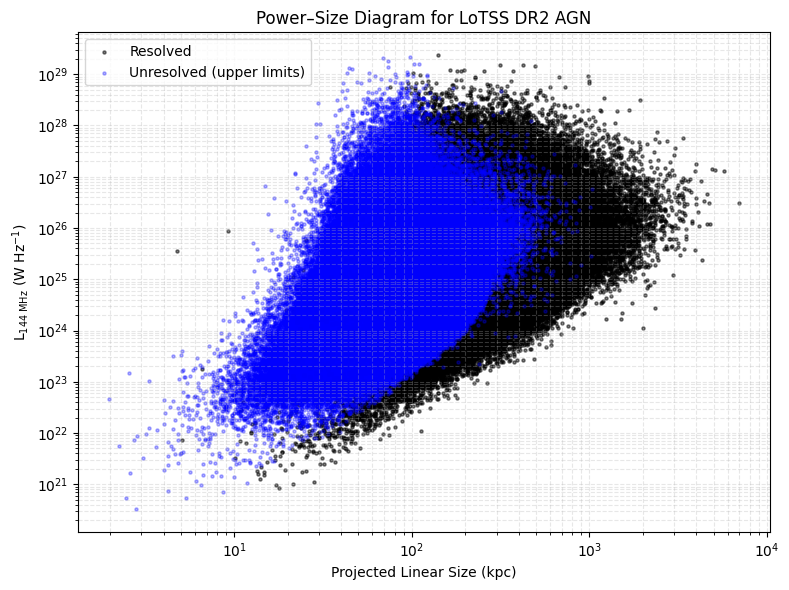

In [ ]:
#trying out the power-size diagram (sanity check on the data)
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.table import Table

# Load catalog
cat = Table.read("../data/agn-v1.0.fits")

# Extract required fields
z = cat['z_best'].data
lum = cat['L_144'].data  # in W/Hz
ang_size_arcsec = cat['LAS'].data  # in arcsec
resolved = cat['Resolved'].data

# Set up cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Convert angular size (arcsec) → radians
ang_size_rad = ang_size_arcsec * (np.pi / (180.0 * 3600.0))

# Compute angular diameter distance in kpc
D_A = cosmo.angular_diameter_distance(z).to(u.kpc).value  # returns array

# Compute projected physical size in kpc
phys_size_kpc = D_A * ang_size_rad

# Create plot
plt.figure(figsize=(8,6))

# Plot resolved sources
plt.scatter(phys_size_kpc[resolved], lum[resolved],
            s=5, c='black', alpha=0.5, label='Resolved')

# Plot unresolved as upper limits
plt.scatter(phys_size_kpc[~resolved], lum[~resolved],
            s=5, c='blue', alpha=0.3, label='Unresolved (upper limits)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Projected Linear Size (kpc)')
plt.ylabel('L$_{144\ \\mathrm{MHz}}$ (W Hz$^{-1}$)')
plt.title('Power–Size Diagram for LoTSS DR2 AGN')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()


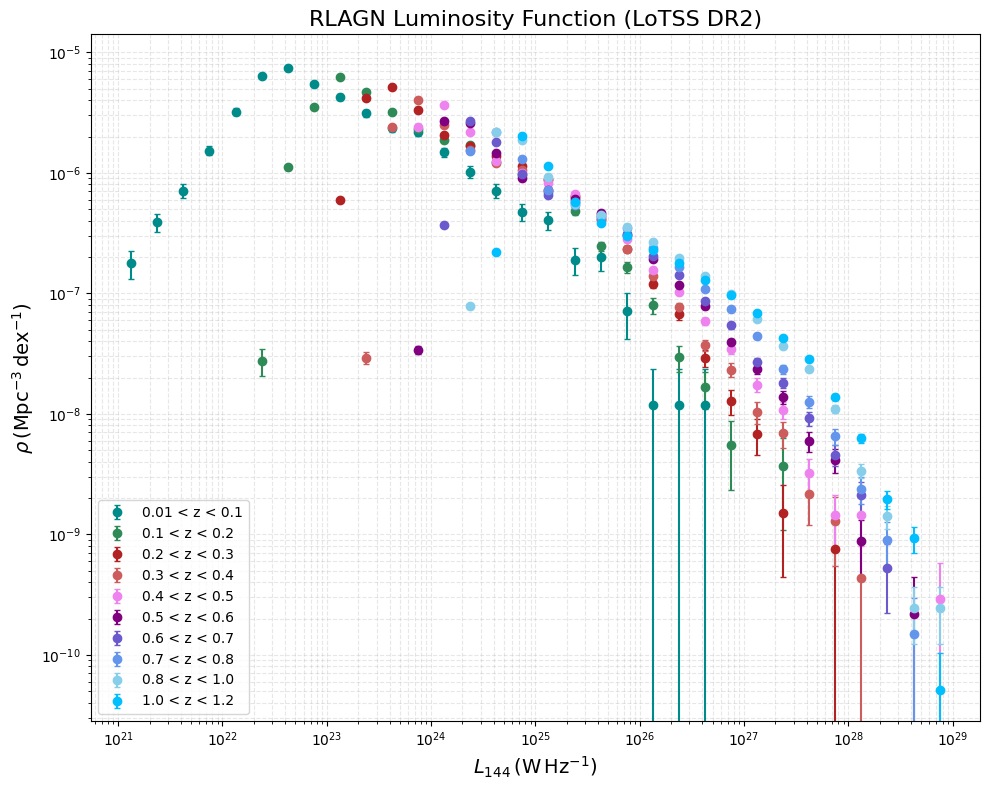

In [ ]:
# Initial Attempt at Plotting the Luminosity Function for RLAGN in LoTSS DR2
# does not account for flux density cut, V_max calculated per bin, rather than per source, poisson error bars using N^1/2, which underestimates error for small bins. 
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.cosmology import Planck15 as cosmo
import astropy.units as u

# File path
data_path = "../data/agn-v1.0.fits"
hdul = fits.open(data_path)
data = hdul[1].data

# Extract relevant columns
z = data['z_best']
L = data['L_144']

# Redshift bins (as in Fig. 11)
z_bins = [(0.01, 0.1), (0.1, 0.2), (0.2, 0.3), (0.3, 0.4), (0.4, 0.5),
          (0.5, 0.6), (0.6, 0.7), (0.7, 0.8), (0.8, 1.0), (1.0, 1.2)]

colors = ['darkcyan', 'seagreen', 'firebrick', 'indianred', 'violet',
          'purple', 'slateblue', 'cornflowerblue', 'skyblue', 'deepskyblue']

# Luminosity bins
logL_bins = np.linspace(21, 29, 33)
bin_width = logL_bins[1] - logL_bins[0]
logL_centers = 0.5 * (logL_bins[:-1] + logL_bins[1:])

plt.figure(figsize=(10, 8))

# Loop over redshift bins
for (zmin, zmax), color in zip(z_bins, colors):
    mask = (z >= zmin) & (z < zmax) & np.isfinite(L)
    z_bin = z[mask]
    L_bin = L[mask]
    if len(L_bin) == 0:
        continue

    logL = np.log10(L_bin)
    counts, _ = np.histogram(logL, bins=logL_bins)
    vol = cosmo.comoving_volume(zmax) - cosmo.comoving_volume(zmin)
    vol = vol.value  # Mpc^3

    rho = counts / (vol * bin_width)
    rho_err = np.sqrt(counts) / (vol * bin_width)

    nonzero = counts > 0
    plt.errorbar(10**logL_centers[nonzero], rho[nonzero], yerr=rho_err[nonzero],
                 fmt='o', color=color, label=f"{zmin} < z < {zmax}", capsize=2)

# Plot formatting
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$L_{144}\,\mathrm{(W\,Hz^{-1})}$", fontsize=14)
plt.ylabel(r"$\rho\,\mathrm{(Mpc^{-3}\,dex^{-1})}$", fontsize=14)
plt.title("RLAGN Luminosity Function (LoTSS DR2)", fontsize=16)
plt.legend(fontsize=10, loc='lower left', frameon=True)
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [2]:
# Second Attempt at Plotting the Luminosity Function for RLAGN in LoTSS DR2
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
from scipy.optimize import root_scalar
from tqdm import tqdm
from astropy.table import Table
from astropy.io import fits
import astropy.units as u

# Constants
alpha = 0.7  # spectral index
S_lim_mJy = 0.5  # LOFAR DR2 flux limit in mJy
S_lim = S_lim_mJy * 1e-29  # Convert mJy to W/m^2/Hz

# LOFAR DR2 survey area
survey_area_deg2 = 5720  # as per the DR2 paper
sky_fraction = survey_area_deg2 / 41252.96  # total sky area in deg^2

# Redshift bins (from paper)
z_bins = [(0.01, 0.1), (0.1, 0.2), (0.2, 0.3), (0.3, 0.4), (0.4, 0.5),
          (0.5, 0.6), (0.6, 0.7), (0.7, 0.8), (0.8, 1.0), (1.0, 1.2)]

# Luminosity bins (log-spaced)
logL_edges = np.linspace(21, 29, 33)
logL_centers = 0.5 * (logL_edges[:-1] + logL_edges[1:])
dlogL = np.diff(logL_edges)[0]

# Store results
all_phi = []
all_err = []

# File path
data_path = "../data/agn-v1.0.fits"
hdul = fits.open(data_path)
data = hdul[1].data


# Loop through redshift bins
for zmin, zmax in z_bins:
    mask = (data['z_best'] > zmin) & (data['z_best'] <= zmax)
    z = data['z_best'][mask]
    L = data['L_144'][mask]
    S_obs = data['Total_flux'][mask] * 1e-29  # mJy to W/m²/Hz
    if len(L) > 0:
        print(f"Bin {zmin}–{zmax}: Max log10(L_144) = {np.max(np.log10(L)):.2f}")
    vmax_list = []
    L_list = []

    for zi, Li, Si in zip(z, L, S_obs):
        # Find zmax where this source would fall below the flux limit
        def flux_limited_z(ztry):
            dl = cosmo.luminosity_distance(ztry).to('m').value
            return Li - (4 * np.pi * dl**2 * S_lim * (1 + ztry)**(alpha - 1))
        try:
            sol = root_scalar(flux_limited_z, bracket=[zi, 5.0], method='brentq')
            zlim = min(sol.root, zmax)
        except Exception:
            zlim = zmax

        # Compute Vmax
        V = (cosmo.comoving_volume(zlim) - cosmo.comoving_volume(zmin)) * sky_fraction
        V = V.to(u.Mpc**3).value
        vmax_list.append(V)
        L_list.append(np.log10(Li))

    vmax_list = np.array(vmax_list)
    L_list = np.array(L_list)

    # Bin in luminosity
    hist_phi = np.zeros(len(logL_centers))
    hist_err = np.zeros(len(logL_centers))

    for i in range(len(logL_edges) - 1):
        mask_bin = (L_list >= logL_edges[i]) & (L_list < logL_edges[i + 1])
        if np.any(mask_bin):
            weights = 1 / vmax_list[mask_bin]
            N_sources = len(weights)
            if N_sources > 10: 
                hist_phi[i] = np.sum(weights) / dlogL
                hist_err[i] = np.sqrt(np.sum(weights**2)) / dlogL
            #switching to poisson error for low counts
            elif N_sources > 3:
                avg_vmax = np.mean(vmax_list[mask_bin])
                hist_phi[i] = np.sum(weights) / dlogL
                hist_err[i] = (np.sqrt(N_sources) / (avg_vmax * dlogL)) if avg_vmax > 0 else np.nan
                #debugging
                print(f"Bin {zmin:.2f}–{zmax:.2f}, logL: {logL_edges[i]:.1f}–{logL_edges[i+1]:.1f}")
                print(f"  N_sources = {N_sources}")
                print(f"  φ = {hist_phi[i]:.2e}")
                print(f"  err = {hist_err[i]:.2e}")
                print(f"  avg_vmax = {avg_vmax:.2e}")
                print(f"  raw weights: {weights}")
                print("---")
            else: #weeding out bins with very few sources
                hist_phi[i] = np.nan
                hist_err[i] = np.nan
        else:
            hist_phi[i] = np.nan
            hist_err[i] = np.nan

    all_phi.append(hist_phi)
    all_err.append(hist_err)

    #Progress update
    #print(f"Done with bin {zmin}–{zmax}, sources used: {len(vmax_list)}")


Bin 0.01–0.1: Max log10(L_144) = 26.53
Bin 0.01–0.10, logL: 25.8–26.0
  N_sources = 6
  φ = 5.11e-07
  err = 2.09e-07
  avg_vmax = 4.70e+07
  raw weights: [2.12950168e-08 2.12950168e-08 2.12950168e-08 2.12950168e-08
 2.12950168e-08 2.12950168e-08]
---
Bin 0.1–0.2: Max log10(L_144) = 27.38
Bin 0.10–0.20, logL: 26.5–26.8
  N_sources = 9
  φ = 1.19e-07
  err = 3.98e-08
  avg_vmax = 3.02e+08
  raw weights: [3.31506867e-09 3.31506867e-09 3.31506867e-09 3.31506867e-09
 3.31506867e-09 3.31506867e-09 3.31506867e-09 3.31506867e-09
 3.31506867e-09]
---
Bin 0.2–0.3: Max log10(L_144) = 27.82
Bin 0.20–0.30, logL: 27.0–27.2
  N_sources = 9
  φ = 4.87e-08
  err = 1.62e-08
  avg_vmax = 7.39e+08
  raw weights: [1.35265436e-09 1.35265436e-09 1.35265436e-09 1.35265436e-09
 1.35265436e-09 1.35265436e-09 1.35265436e-09 1.35265436e-09
 1.35265436e-09]
---
Bin 0.3–0.4: Max log10(L_144) = 28.22
Bin 0.30–0.40, logL: 27.5–27.8
  N_sources = 5
  φ = 1.55e-08
  err = 6.92e-09
  avg_vmax = 1.29e+09
  raw weights: 

0.01–0.1: max L = 7.50e+25
0.1–0.2: max L = 4.22e+26
0.2–0.3: max L = 1.33e+27
0.3–0.4: max L = 4.22e+27
0.4–0.5: max L = 1.33e+28
0.5–0.6: max L = 1.33e+28
0.6–0.7: max L = 1.33e+28
0.7–0.8: max L = 2.37e+28
0.8–1.0: max L = 7.50e+28
1.0–1.2: max L = 4.22e+28


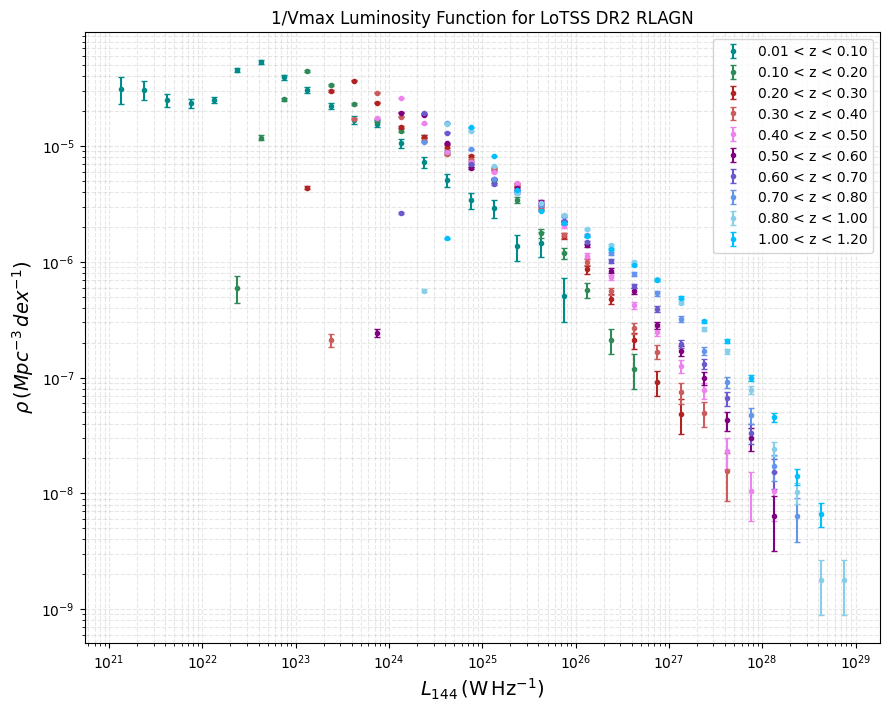

In [3]:
#plotting the results (separate for debugging purposes)
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(z_bins)))
plt.figure(figsize=(9, 7))

colors = ['darkcyan', 'seagreen', 'firebrick', 'indianred', 'violet',
          'purple', 'slateblue', 'cornflowerblue', 'skyblue', 'deepskyblue']

for i, (phi, err) in enumerate(zip(all_phi, all_err)):
    label = f"{z_bins[i][0]:.2f} < z < {z_bins[i][1]:.2f}"
    mask = ~np.isnan(phi)
    if np.any(mask):
        print(f"{z_bins[i][0]}–{z_bins[i][1]}: max L = {10**logL_centers[mask][-1]:.2e}")
    plt.errorbar(10**logL_centers, phi, yerr=err, fmt='.', color=colors[i], label=label, capsize=2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$L_{144}\,\mathrm{(W\,Hz^{-1})}$', fontsize=14)
plt.ylabel(r'$\rho\,(Mpc^{-3}\,dex^{-1})$', fontsize=14)
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.3)
plt.tight_layout()
plt.title('1/Vmax Luminosity Function for LoTSS DR2 RLAGN')
plt.show()


Running burn-in...


100%|██████████| 500/500 [00:00<00:00, 1390.67it/s]


Running production...


100%|██████████| 1000/1000 [00:00<00:00, 1467.61it/s]


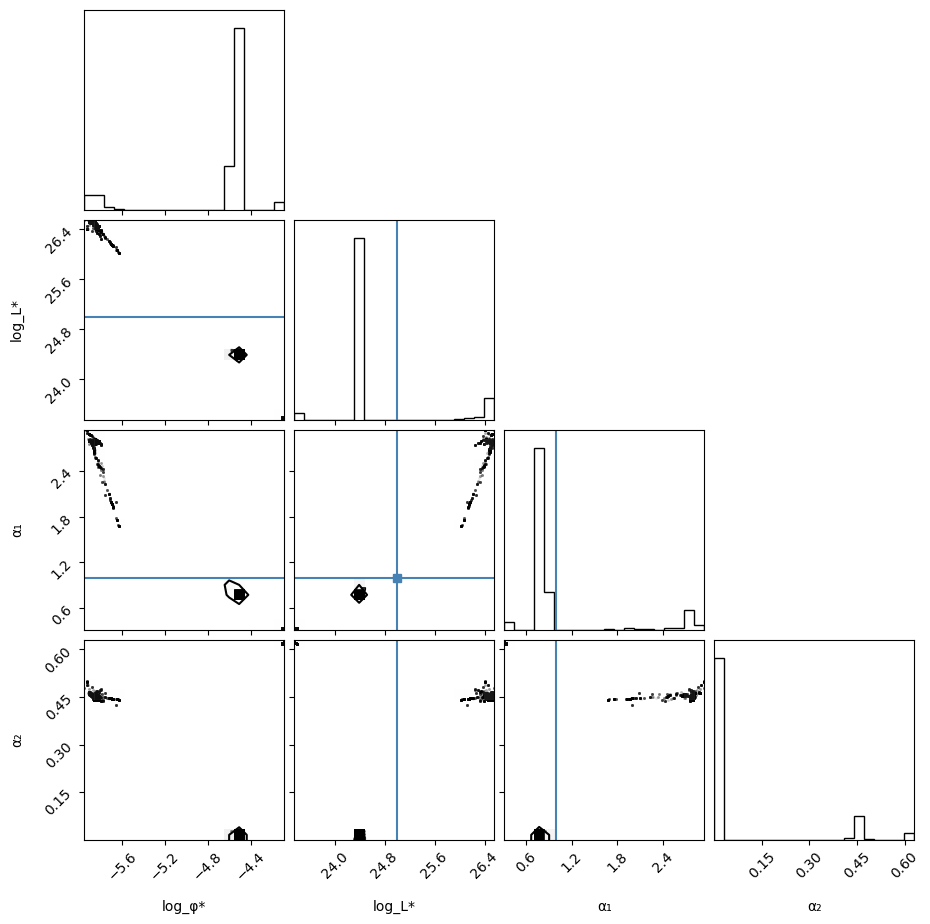

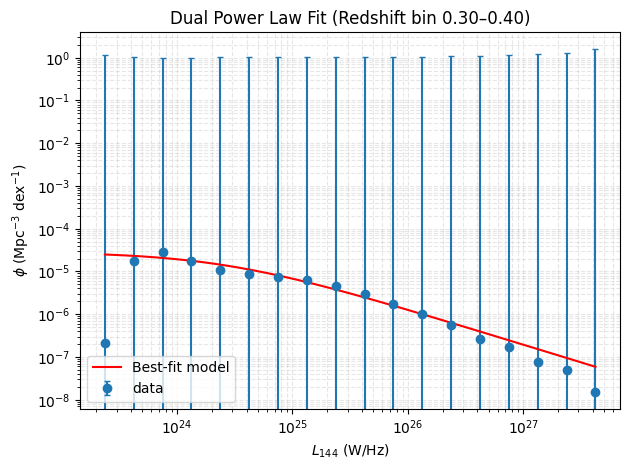

In [4]:
# Fitting the Dual Power Law Model to the Luminosity Function
# This code uses MCMC to fit the dual power law model to the luminosity function data
# Test for one redshift bin
import numpy as np
import emcee
import corner
import matplotlib.pyplot as plt

# Use one redshift bin's data
i = 3  # for example, bin 0.3 < z < 0.4
logL = logL_centers
logphi = np.log10(all_phi[i])
logerr = all_err[i] / (all_phi[i] * np.log(10))  # convert dphi to dlog10phi

# Mask NaNs and infs
mask = np.isfinite(logphi) & np.isfinite(logerr)
logL = logL[mask]
logphi = logphi[mask]
logerr = logerr[mask]

# --- MODEL ---
def model(logL, log_phi_star, log_L_star, alpha1, alpha2):
    L = 10**logL
    L_star = 10**log_L_star
    phi_star = 10**log_phi_star
    return np.log10(phi_star / ((L / L_star)**alpha1 + (L / L_star)**alpha2))

# --- PRIORS ---
def log_prior(theta):
    log_phi_star, log_L_star, alpha1, alpha2 = theta
    if -10 < log_phi_star < 0 and 22 < log_L_star < 28 and 0 < alpha1 < 3 and 0 < alpha2 < 6:
        return 0.0
    return -np.inf

# --- LIKELIHOOD ---
def log_likelihood(theta, x, y, yerr):
    return -0.5 * np.sum(((y - model(x, *theta)) / yerr)**2)

def log_posterior(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

# --- INITIALIZE ---
ndim = 4
nwalkers = 32
p0 = np.array([ -4, 25, 1.0, 2.0 ])  # initial guess
pos = p0 + 1e-4 * np.random.randn(nwalkers, ndim)

# --- RUN MCMC ---
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(logL, logphi, logerr))
print("Running burn-in...")
sampler.run_mcmc(pos, 500, progress=True)
sampler.reset()

print("Running production...")
sampler.run_mcmc(None, 1000, progress=True)
samples = sampler.get_chain(flat=True)

# --- CORNER PLOT ---
fig = corner.corner(samples, labels=["log_φ*", "log_L*", "α₁", "α₂"], truths=p0)
plt.show()

# --- BEST FIT CURVE ---
theta_best = np.median(samples, axis=0)
logL_fit = np.linspace(min(logL), max(logL), 200)
logphi_fit = model(logL_fit, *theta_best)

plt.errorbar(10**logL, 10**logphi, yerr=10**logerr, fmt='o', label="data", capsize=2)
plt.plot(10**logL_fit, 10**logphi_fit, 'r-', label="Best-fit model")
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$L_{144}$ (W/Hz)')
plt.ylabel(r'$\phi$ (Mpc$^{-3}$ dex$^{-1}$)')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.3)
plt.title("Dual Power Law Fit (Redshift bin {:.2f}–{:.2f})".format(*z_bins[i]))
plt.tight_layout()
plt.show()
